# **ClimateGuard AI**

In [ ]:
!pip install tensorflow plotly seaborn streamlit pyngrok

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

import plotly.graph_objects as go


In [ ]:
df = pd.read_csv("GlobalWeatherRepository.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91226 entries, 0 to 91225
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       91226 non-null  object 
 1   location_name                 91226 non-null  object 
 2   latitude                      91226 non-null  float64
 3   longitude                     91226 non-null  float64
 4   timezone                      91226 non-null  object 
 5   last_updated_epoch            91226 non-null  int64  
 6   last_updated                  91226 non-null  object 
 7   temperature_celsius           91226 non-null  float64
 8   temperature_fahrenheit        91226 non-null  float64
 9   condition_text                91226 non-null  object 
 10  wind_mph                      91226 non-null  float64
 11  wind_kph                      91225 non-null  float64
 12  wind_degree                   91225 non-null  float64
 13  w

In [ ]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

### **FEATURE SELECTION**

In [ ]:
features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'visibility_km',
    'uv_index',
    'cloud',
    'feels_like_celsius',
    'gust_kph'
]
df = df[features]
df.head()

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,visibility_km,uv_index,cloud,feels_like_celsius,gust_kph
0,26.6,24.0,1012.0,13.3,0.0,10.0,7.0,30.0,25.3,15.3
1,19.0,94.0,1012.0,11.2,0.1,10.0,5.0,75.0,19.0,18.4
2,23.0,29.0,1011.0,15.1,0.0,10.0,5.0,0.0,24.6,22.3
3,6.3,61.0,1007.0,11.9,0.3,2.0,2.0,100.0,3.8,13.7
4,26.0,89.0,1011.0,13.0,0.0,10.0,8.0,50.0,28.7,20.2


In [ ]:
df.dropna(inplace=True)
print(df.shape)


(91225, 10)


### **VISUALIZATION**

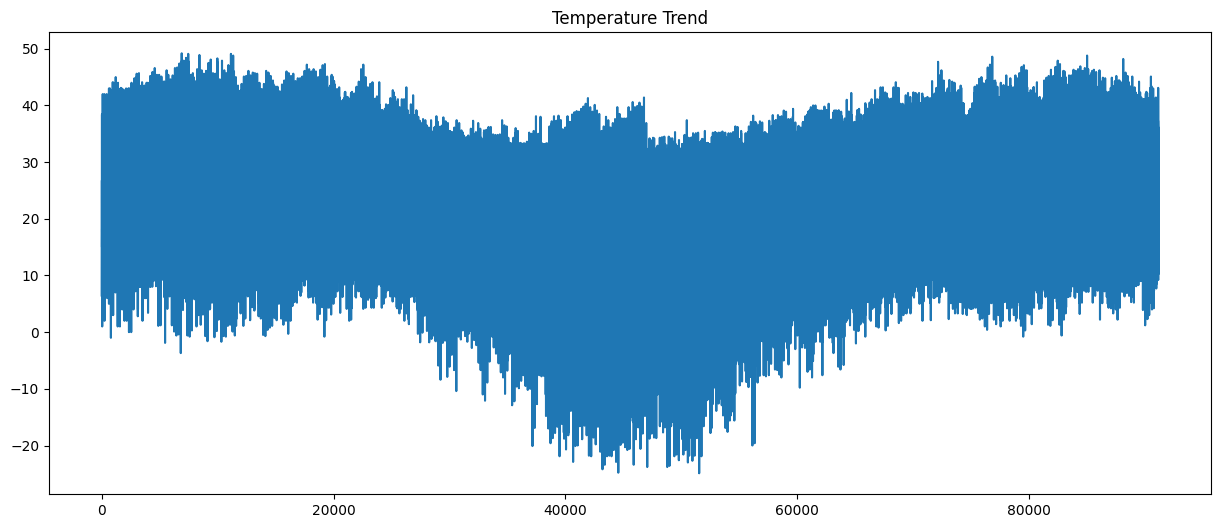

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    df["temperature_celsius"]
)

plt.title(
    "Temperature Trend"
)

plt.show()

### **CORRELATION HEATMAP**

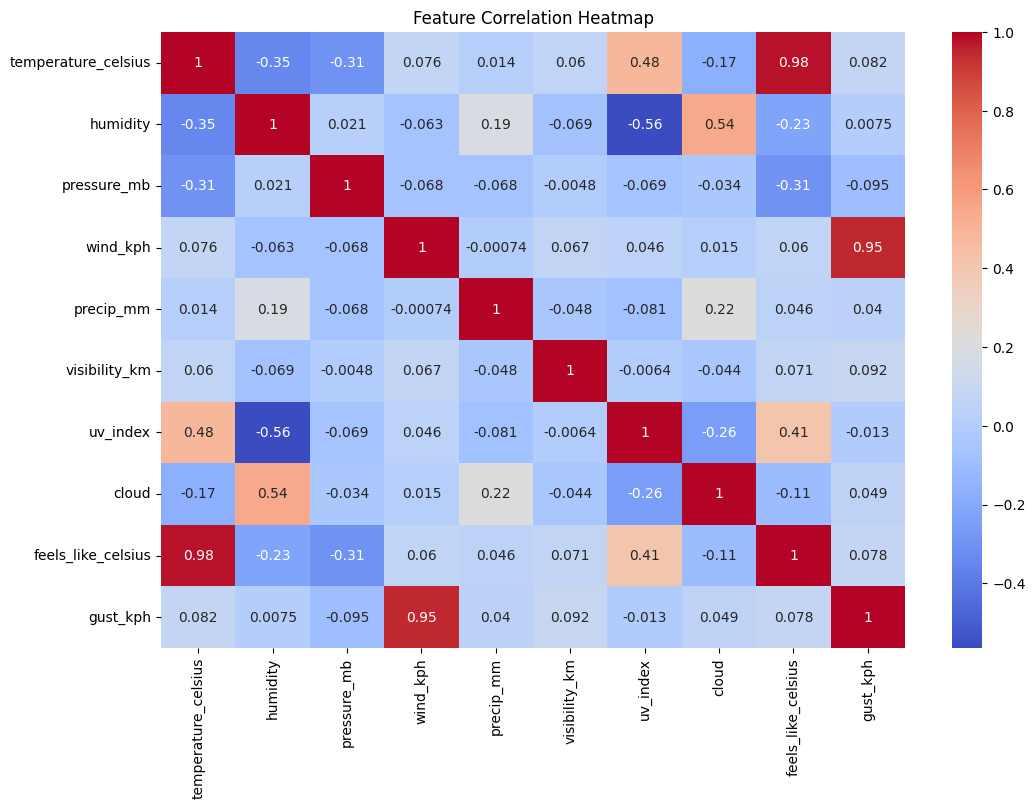

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Feature Correlation Heatmap"
)
plt.show()

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

print(scaled_data.shape)

(91225, 10)


In [ ]:
SEQ_LENGTH = 10

x = []
y = []

for i in range(
    SEQ_LENGTH,
    len(scaled_data)
):


    x.append(
        scaled_data[
        i-SEQ_LENGTH:i
    ]
)
    y.append(
        scaled_data[i][0]
)

x = np.array(x)
y = np.array(y)

print(x.shape)
print(y.shape)


(91215, 10, 10)
(91215,)


### **TRAIN TEST SPLIT**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    shuffle=False
)

print(x_train.shape)
print(x_test.shape)


(72972, 10, 10)
(18243, 10, 10)


### **BUILD LSTM MODEL**

In [ ]:
model = Sequential([
    Input(
        shape=(
            SEQ_LENGTH,
            x.shape[2]
    )

    ),
    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(64),

    Dropout(0.2),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,289 (204.25 KB)

 Trainable params: 52,289 (204.25 KB)

 Non-trainable params: 0 (0.00 B)

### **TRAIN MODEL**

In [ ]:
history = model.fit(
    x_train,
    y_train,

    epochs=20,

    batch_size=32,

    validation_data=(
        x_test,
        y_test
    )
)

Epoch 1/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 53s 21ms/step - loss: 0.0175 - val_loss: 0.0118
Epoch 2/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0155 - val_loss: 0.0110
Epoch 3/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0142 - val_loss: 0.0115
Epoch 4/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 0.0130 - val_loss: 0.0113
Epoch 5/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0111 - val_loss: 0.0134
Epoch 6/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0091 - val_loss: 0.0103
Epoch 7/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 0.0075 - val_loss: 0.0091
Epoch 8/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0064 - val_loss: 0.0098
Epoch 9/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0056 - val_loss: 0.0092
Epoch 10/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0050 - val_loss: 0.0089
Epoch 11/20
2281/2281 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0045 - val_loss: 0.0081
Epoch 12

### **TRAINING GRAPH**

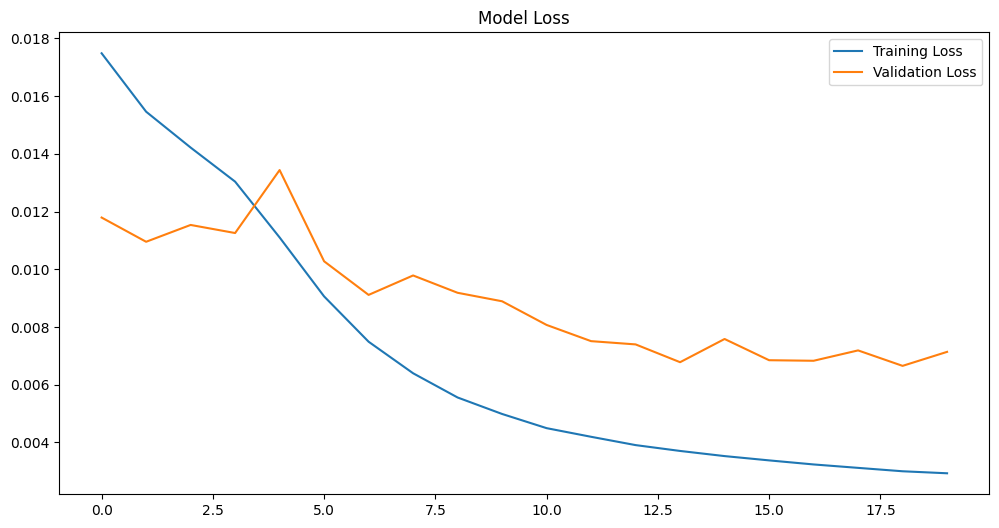

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title("Model Loss")

plt.show()

### **PREDICTIONS**

In [ ]:
predictions = model.predict(x_test)

571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


### **INVERSE TRANSFORM**

In [ ]:
dummy = np.zeros(
    (
        len(predictions),
        len(features)
    )
)

dummy[:,0] = predictions.flatten()

predictions_actual = scaler.inverse_transform(dummy)[:,0]

dummy2 = np.zeros(
    (
        len(y_test),
        len(features)
    )
)

dummy2[:,0] = y_test

y_test_actual = scaler.inverse_transform(dummy2)[:,0]

### **EVALUATION**

In [ ]:
mse = mean_squared_error(
    y_test_actual,
    predictions_actual
)

mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

print("MSE:", mse)
print("MAE:", mae)

MSE: 39.193260397676305
MAE: 4.748317832821119


### **ACTUAL VS PREDICTED GRAPH**

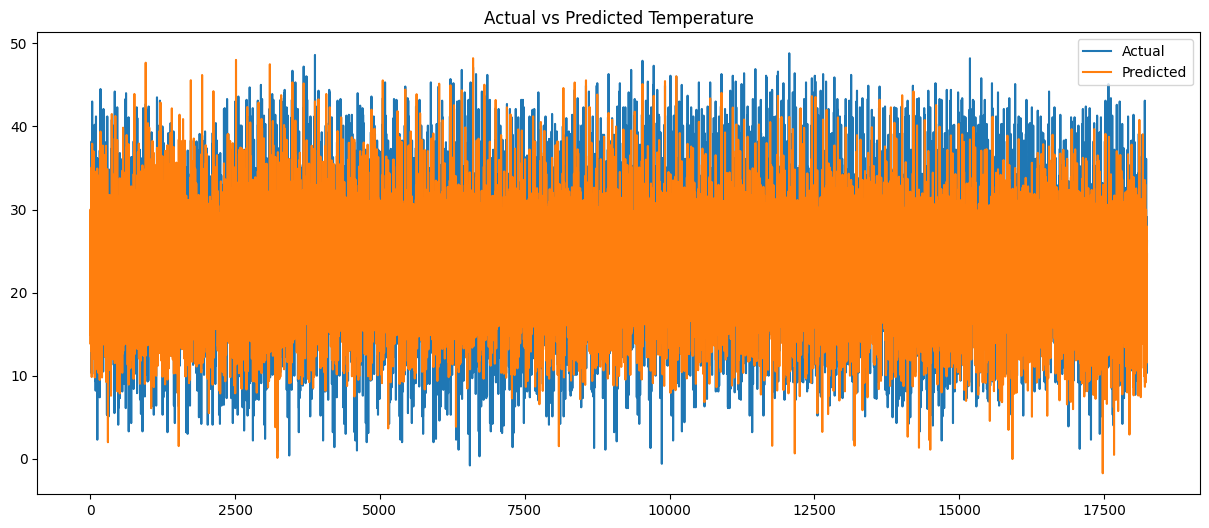

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    predictions_actual,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Temperature"
)

plt.show()

### **FUTURE FORECASTING**

In [ ]:
future_days = 30

last_sequence = x_test[-1]

future_predictions = []


In [ ]:
current_sequence = last_sequence.reshape(
    1,
    SEQ_LENGTH,
    len(features)
)

for _ in range(future_days):
  next_pred = model.predict(current_sequence, verbose=0)

  future_predictions.append(
      next_pred[0][0]
  )

  next_step = current_sequence[0,-1,:].copy()

  next_step[0] = next_pred[0][0]

  current_sequence = np.append(
      current_sequence[:,1:,:],
      [[next_step]],
      axis=1
  )


In [ ]:
future_predictions = np.array(
    future_predictions
).reshape(-1,1)

In [ ]:
dummy_future = np.zeros(
    (
        len(future_predictions),
        len(features)
    )
)

dummy_future[:,0] = future_predictions.flatten()

future_actual = scaler.inverse_transform(dummy_future)[:,0]

### **FUTURE GRAPH**

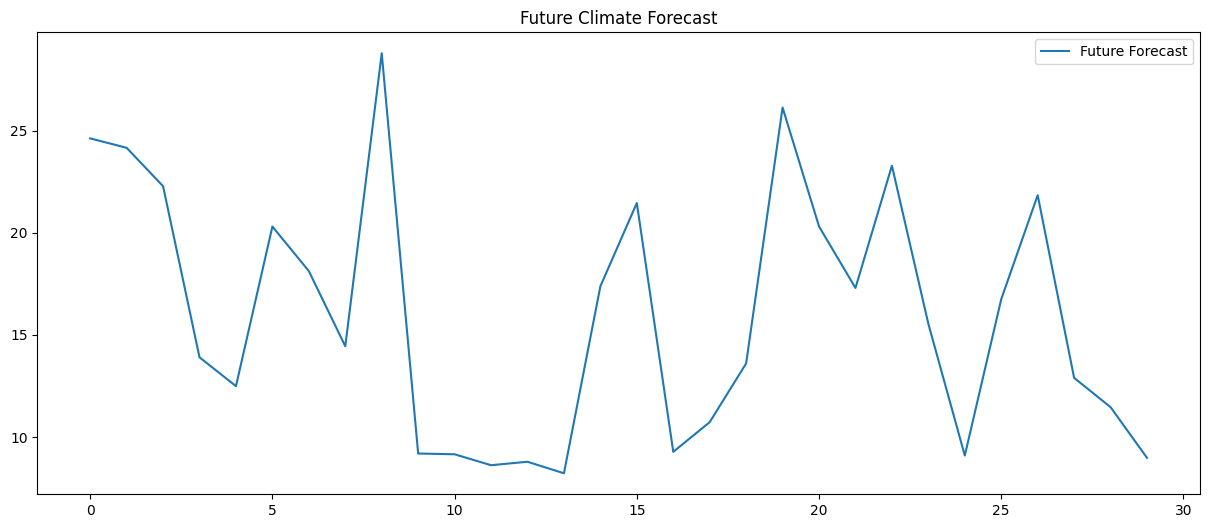

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    future_actual,
    label='Future Forecast'
)

plt.legend()
plt.title("Future Climate Forecast")
plt.show()

### **RISK ANALYSIS**

In [ ]:
risk_threshold = np.mean(
    future_actual
)

risk_labels = np.where(
    future_actual > risk_threshold,

    "High Risk",

    "Moderate Risk"
)

forecast_df = pd.DataFrame({
    'Day' : np.arange(
        1,
        future_days + 1
    ),

    'predictedTemperature' : future_actual,

    'RiskLevel' : risk_labels
})

forecast_df.head()

,Day,predictedTemperature,RiskLevel
0,1,24.626297,High Risk
1,2,24.164367,High Risk
2,3,22.283567,High Risk
3,4,13.902628,Moderate Risk
4,5,12.491464,Moderate Risk


### **SAVE FORECAST**

In [ ]:
forecast_df.to_csv(
    "future_climate_forecast.csv",
    index=False
)

print("✅ Forecast saved!")

✅ Forecast saved!


### **SAVE MODEL**

In [ ]:
model.save(
    "Climateguard_ai_model.keras"
)
print("✅ Model saved!")

✅ Model saved!


In [ ]:
!pip install streamlit pyngrok tensorflow plotly

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token(
    "3DfoEckJejcy4PgzUi7WRyKNexx_53PgPZ6sU4ovw6DEpT4Ye"
)

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np

from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

import plotly.graph_objects as go


st.set_page_config(
    page_title="ClimateGuard AI",
    layout="wide"
)


st.title("🌍 ClimateGuard AI")

st.subheader(
    "Multi-Feature Climate Forecasting System"
)


df = pd.read_csv(
    "GlobalWeatherRepository.csv"
)


features = [

    'temperature_celsius',

    'humidity',

    'pressure_mb',

    'wind_kph',

    'precip_mm',

    'visibility_km',

    'uv_index',

    'cloud',

    'feels_like_celsius',

    'gust_kph'
]

df = df[features]

df.dropna(inplace=True)


scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)


model = load_model(
    "Climateguard_ai_model.keras"
)


SEQ_LENGTH = 10

X = []

for i in range(
    SEQ_LENGTH,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-SEQ_LENGTH:i
        ]
    )

X = np.array(X)


future_days = st.slider(

    "Select Forecast Days",

    1,

    30,

    7
)


last_sequence = X[-1]

future_predictions = []

current_sequence = last_sequence.reshape(

    1,

    SEQ_LENGTH,

    len(features)
)

for _ in range(future_days):

    next_pred = model.predict(

        current_sequence,

        verbose=0
    )

    future_predictions.append(
        next_pred[0][0]
    )

    next_step = current_sequence[
        0,-1,:
    ].copy()

    next_step[0] = next_pred[0][0]

    current_sequence = np.append(

        current_sequence[:,1:,:],

        [[next_step]],

        axis=1
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)


dummy_future = np.zeros(

    (
        len(future_predictions),

        len(features)
    )
)

dummy_future[:,0] = (
    future_predictions.flatten()
)

future_actual = scaler.inverse_transform(

    dummy_future

)[:,0]


risk_threshold = np.mean(
    future_actual
)

risk_labels = np.where(

    future_actual > risk_threshold,

    "High Risk",

    "Moderate Risk"
)

forecast_df = pd.DataFrame({

    'Day': np.arange(

        1,

        future_days + 1
    ),

    'PredictedTemperature':
    future_actual,

    'RiskLevel':
    risk_labels
})


st.subheader(
    "📊 Forecast Data"
)

st.dataframe(forecast_df)


fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=forecast_df['Day'],

        y=forecast_df[
            'PredictedTemperature'
        ],

        mode='lines+markers',

        name='Forecast'
    )
)

fig.update_layout(

    title="Future Climate Forecast",

    xaxis_title="Days",

    yaxis_title="Temperature"
)

st.plotly_chart(

    fig,

    use_container_width=True
)


high_risk = len(

    forecast_df[
        forecast_df['RiskLevel']
        == "High Risk"
    ]
)

moderate_risk = len(

    forecast_df[
        forecast_df['RiskLevel']
        == "Moderate Risk"
    ]
)

col1, col2 = st.columns(2)

col1.metric(
    "🔥 High Risk Days",
    high_risk
)

col2.metric(
    "⚠ Moderate Risk Days",
    moderate_risk
)


st.success(
    "✅ Climate Forecast Generated Successfully!"
)

st.markdown("---")

st.markdown(
    "Developed using LSTM Deep Learning"
)


Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://borough-boned-clump.ngrok-free.dev" -> "http://localhost:8501"
